# SESSION 05: IMAGE RESTORATION

- Ex5_1: bold text- Apply simple filters to a noisy image (convolution)
- Ex5_2: Subsampling Image
- Ex5_3: Noise reduction using mean filter
- Ex5_4: Salt/Pepper Noise Reduction using Min/Max Filter
- Ex5_5: Noise Reduction using Low-Pass Filter (LPF)
- Ex5_6: Noise Reduction using Band Reject Filter (BRF)

In [11]:
# connect GG Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Create a path link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_05/'

# Font size for figures
FS = 12

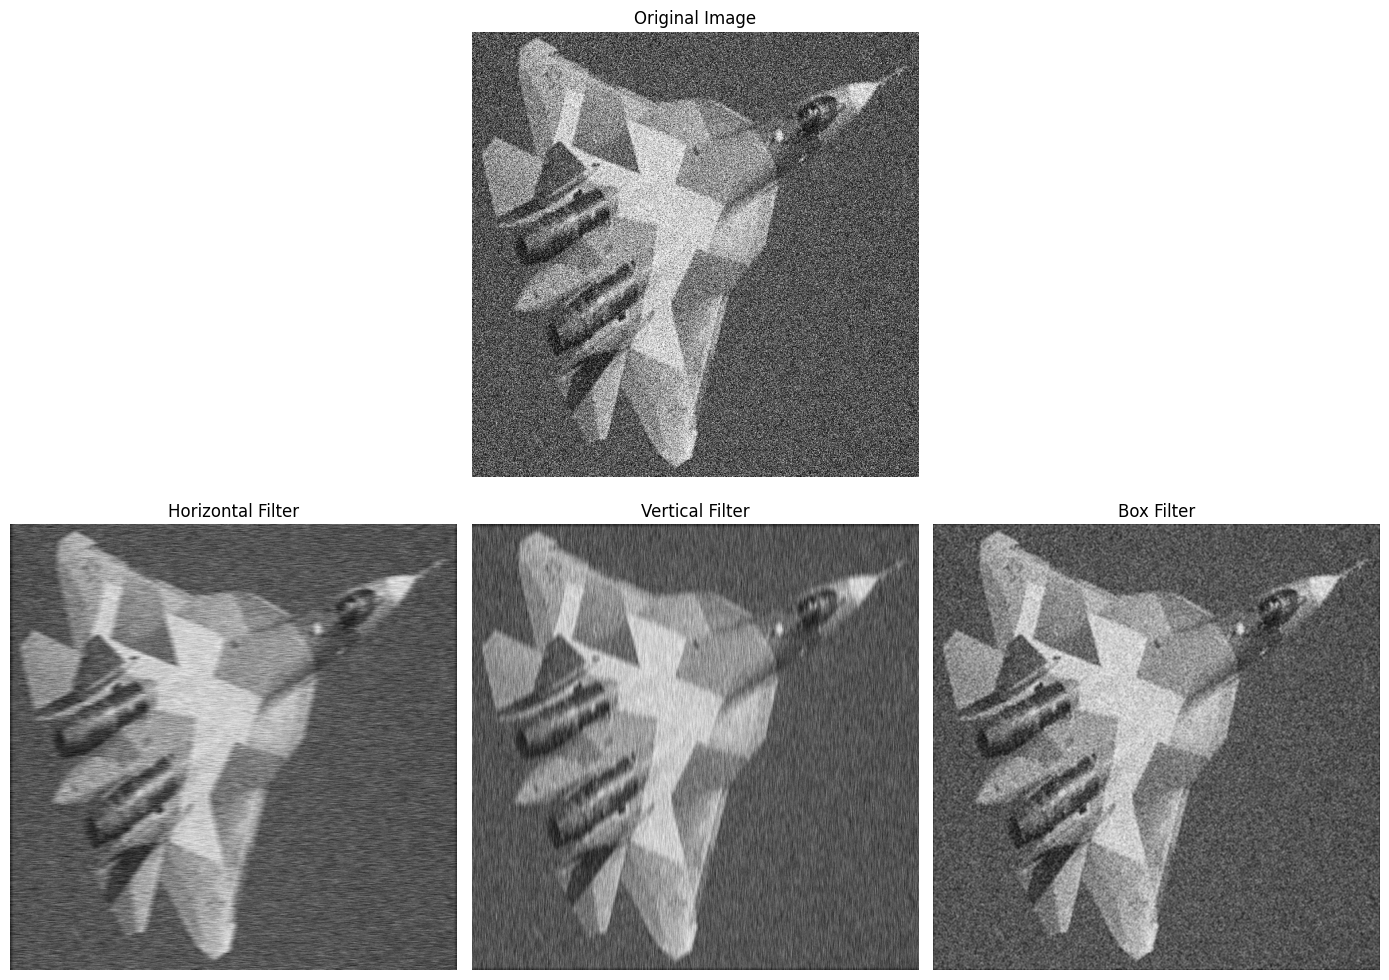

In [14]:
# Ex5_1: Apply simple filters to a noisy image (convolution)
Img = cv2.imread(PATH + 'airplane.png')

# Convert from BGR to RGB, then normalize to double format (0.0000 -> 1.0000)
Img = cv2.cvtColor(Img, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0

# Create three simple filters
f1 = np.ones((1,10), np.float64) / 10 # horizontal filter
f2 = np.ones((10,1), np.float64) / 10 # vertical filter
f3 = np.ones((3,3), np.float64) / 9  # average filter

# Perform the convolution between the noisy image and the filters
filtered_Img1 = cv2.filter2D(Img, -1, f1, borderType = cv2.BORDER_CONSTANT)
filtered_Img2 = cv2.filter2D(Img, -1, f2, borderType = cv2.BORDER_CONSTANT)
filtered_Img3 = cv2.filter2D(Img, -1, f3, borderType = cv2.BORDER_CONSTANT)

# Display results
plt.figure(figsize = (14,10))

plt.subplot(2,3,2), plt.imshow(Img), plt.title('Original Image', fontsize = FS)
plt.axis('off')

plt.subplot(2,3,4), plt.imshow(filtered_Img1), plt.title('Horizontal Filter', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,5), plt.imshow(filtered_Img2), plt.title('Vertical Filter', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,6), plt.imshow(filtered_Img3), plt.title('Box Filter', fontsize = FS)
plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex5_1.jpg', dpi=400)
plt.show()


(256, 256)
(128, 128)
(128, 128)


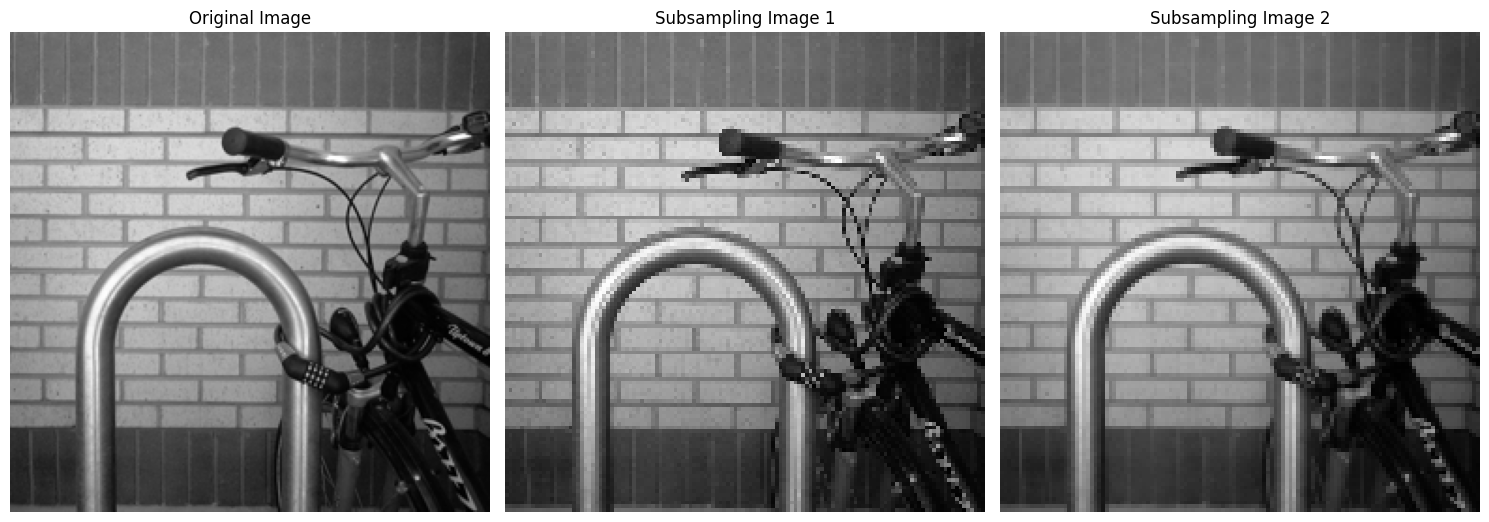

In [15]:
# Ex5_2: Subsampling Image
Img = cv2.imread(PATH + 'bike.png')

Img = cv2.cvtColor(Img, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

# Check dimension of orginal image
row, col = Img.shape
print(Img.shape)

# Create 2 matrices to subsampling the image (ratio: 2:1)
a = np.eye(row // 2, dtype=np.float64)
b = np.array([[1.0],[0.0]], dtype=np.float64)
c = np.array([[0.5],[0.5]], dtype=np.float64)

# Use 2 matrices to create filters
h1 = np.kron(a, b)
h2 = np.kron(a, c)

# Subsampling the orginal image using these filters
sub_Img1 = h1.T @ Img @ h1
sub_Img2 = h2.T @ Img @ h2

# Check dimensions of 2 subsampled images
print(sub_Img1.shape)
print(sub_Img2.shape)

# Display results
plt.figure(figsize=(15,10))

plt.subplot(1,3,1)
plt.imshow(Img, cmap='gray')
plt.title('Original Image', fontsize=FS)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sub_Img1, cmap='gray')
plt.title('Subsampling Image 1', fontsize=FS)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sub_Img2, cmap='gray')
plt.title('Subsampling Image 2', fontsize=FS)
plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex5_2.jpg')
plt.show()

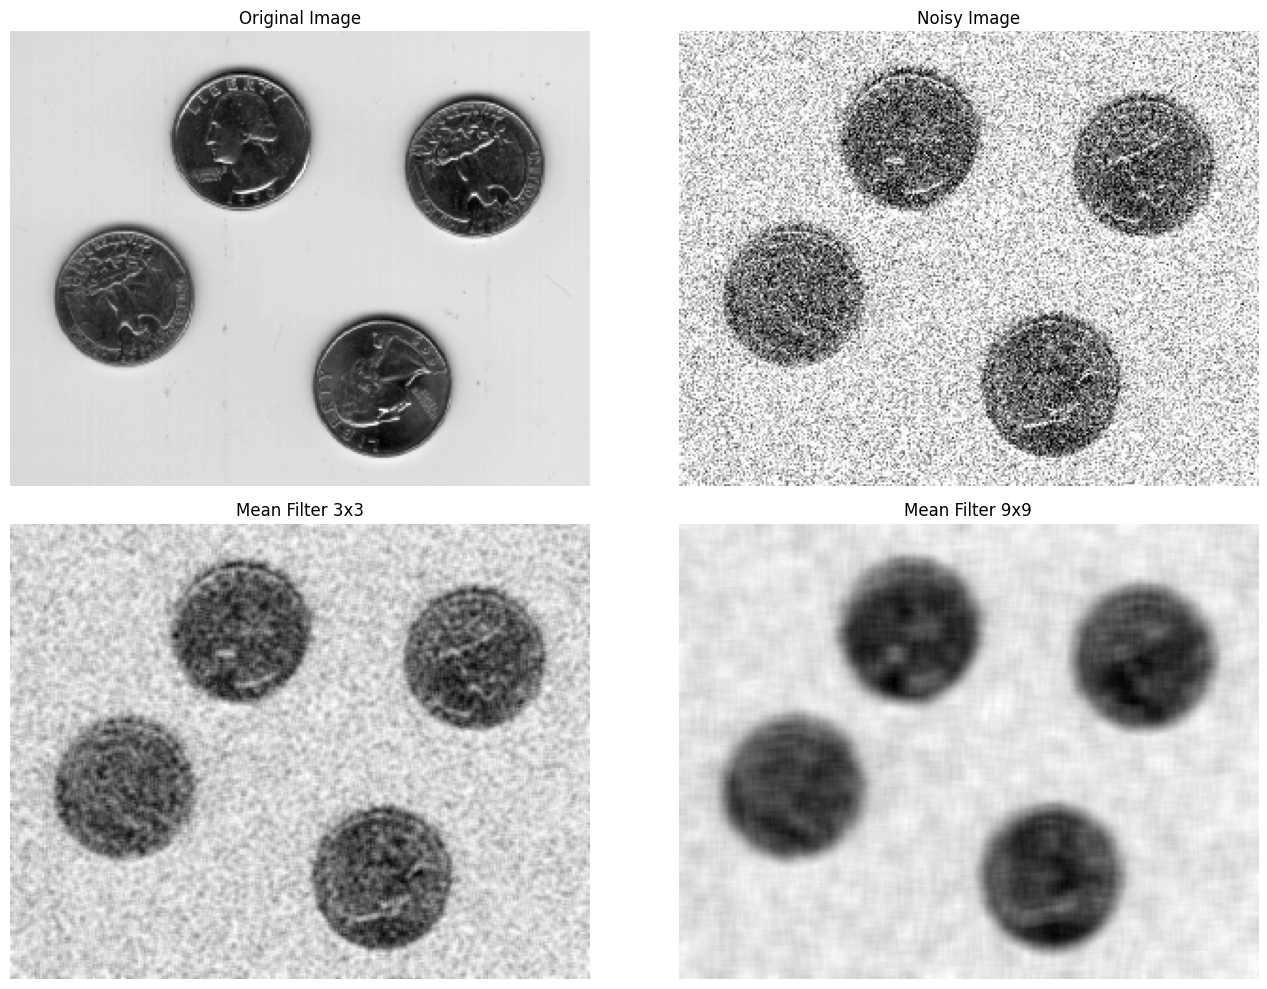

In [16]:
#Ex5_3: Noise reduction using mean filter

Img = cv2.imread(PATH + 'coins.tif')

# convert from BGR to GRAYSCALE, then normalize to double format (0.0000 -> 1.0000)
Img = cv2.cvtColor(Img, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

# Add Gaussian noise to the original image (e.g. mean=0, variance=0.05)
mean, variance = 0, 0.05
sigma = np.sqrt(0.05)  #standard deviation

# Create a matrix of noise = dimensions of the original image
noise = np.random.normal(mean, sigma, Img.shape)
noisy_Img = np.clip(Img + noise, 0, 1)

# Create two different mean filters
m1 = np.ones((3,3), np.float64) / 9
m2 = np.ones((9,9), np.float64) / 81

# Denoise the noisy image using two filters
Img_denoise1 = cv2.filter2D(noisy_Img, -1, m1, borderType=cv2.BORDER_REFLECT)
Img_denoise2 = cv2.filter2D(noisy_Img, -1, m2, borderType=cv2.BORDER_REFLECT)

# Display results
plt.figure(figsize=(14,10))

plt.subplot(2, 2, 1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 2), plt.imshow(noisy_Img, cmap='gray'), plt.title('Noisy Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 3), plt.imshow(Img_denoise1, cmap='gray'), plt.title('Mean Filter 3x3', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 4), plt.imshow(Img_denoise2, cmap='gray'), plt.title('Mean Filter 9x9', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex5_3.jpg', dpi=400)
plt.show()



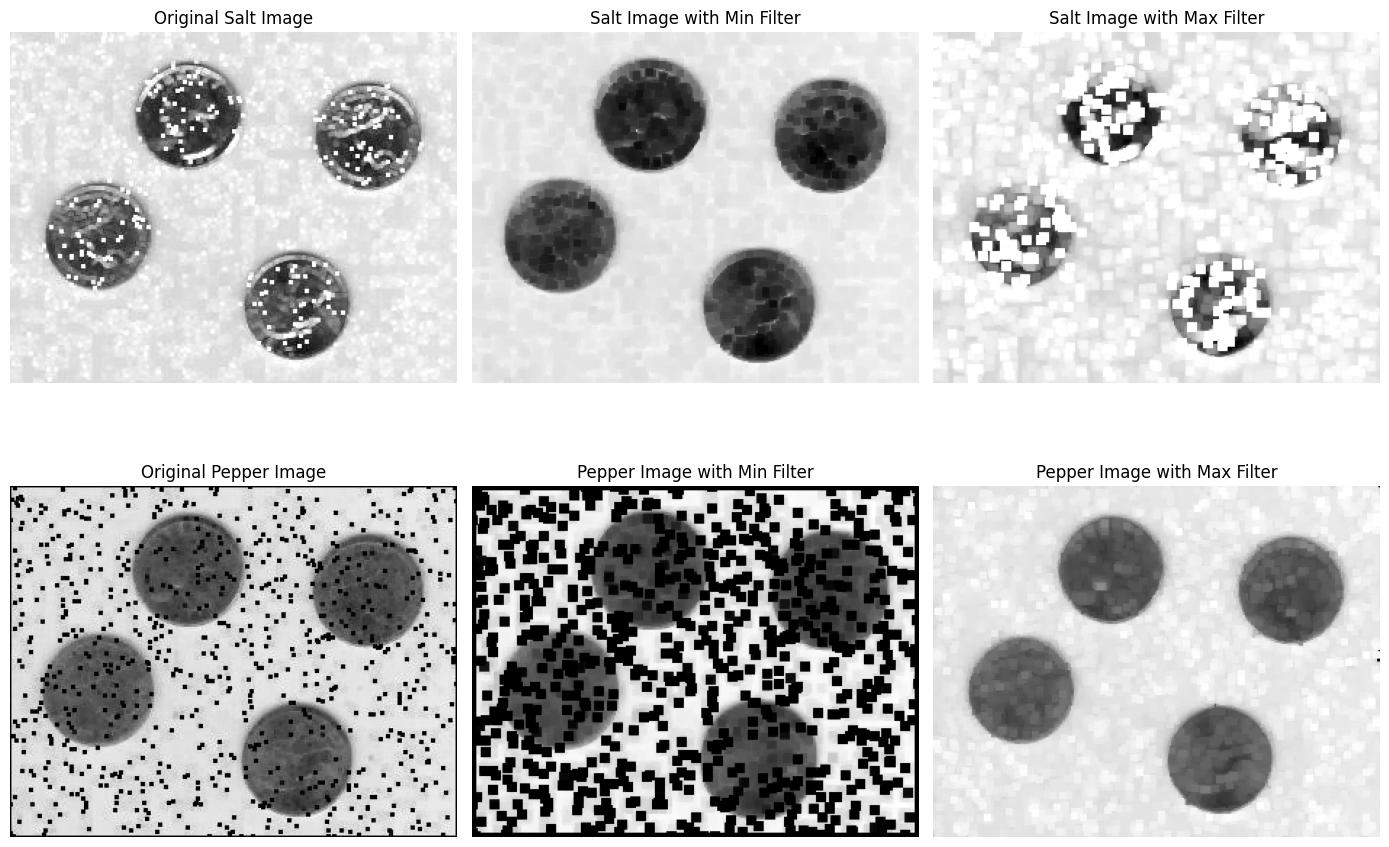

In [17]:
# Ex5_4: Salt/Pepper Noise Reduction using Min/Max Filter
Img_salt = cv2.imread(PATH + 'coins_salt.jpg')
Img_pepper = cv2.imread(PATH + 'coins_pepper.jpg')

# Convert from BGR to GRAYSCALE, then normalize to double format (0.0000 -> 1.000)
Img_salt = cv2.cvtColor(Img_salt, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
Img_pepper = cv2.cvtColor(Img_pepper, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

# Create a simple filter (e.g. 5x5)
filter = np.ones((5,5), np.float64) / 25

# Salt noise: try min and max filters
Img_salt_min = cv2.erode(Img_salt, filter, iterations=1)
Img_salt_max = cv2.dilate(Img_salt, filter, iterations=1)

# Pepper noise: try min and max filter
Img_pepper_min = cv2.erode(Img_pepper, filter, iterations=1)
Img_pepper_max = cv2.dilate(Img_pepper, filter, iterations=1)

# Display results
plt.figure(figsize = (14,10))

plt.subplot(2,3,1), plt.imshow(Img_salt, cmap='gray'), plt.title('Original Salt Image', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,2), plt.imshow(Img_salt_min, cmap='gray'), plt.title('Salt Image with Min Filter', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,3), plt.imshow(Img_salt_max, cmap='gray'), plt.title('Salt Image with Max Filter', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,4), plt.imshow(Img_pepper, cmap='gray'), plt.title('Original Pepper Image', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,5), plt.imshow(Img_pepper_min, cmap='gray'), plt.title('Pepper Image with Min Filter', fontsize = FS)
plt.axis('off')
plt.subplot(2,3,6), plt.imshow(Img_pepper_max, cmap='gray'), plt.title('Pepper Image with Max Filter', fontsize = FS)
plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex5_4.jpg', dpi=400)
plt.show()

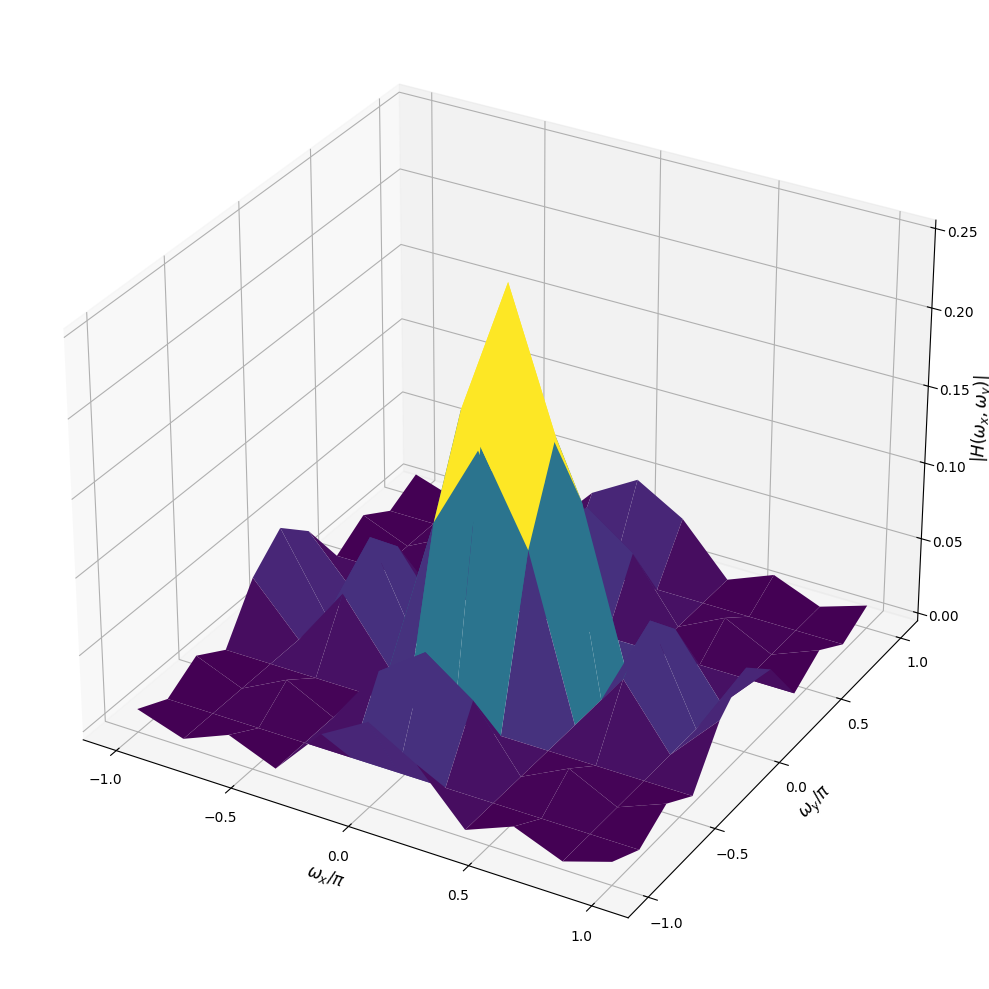

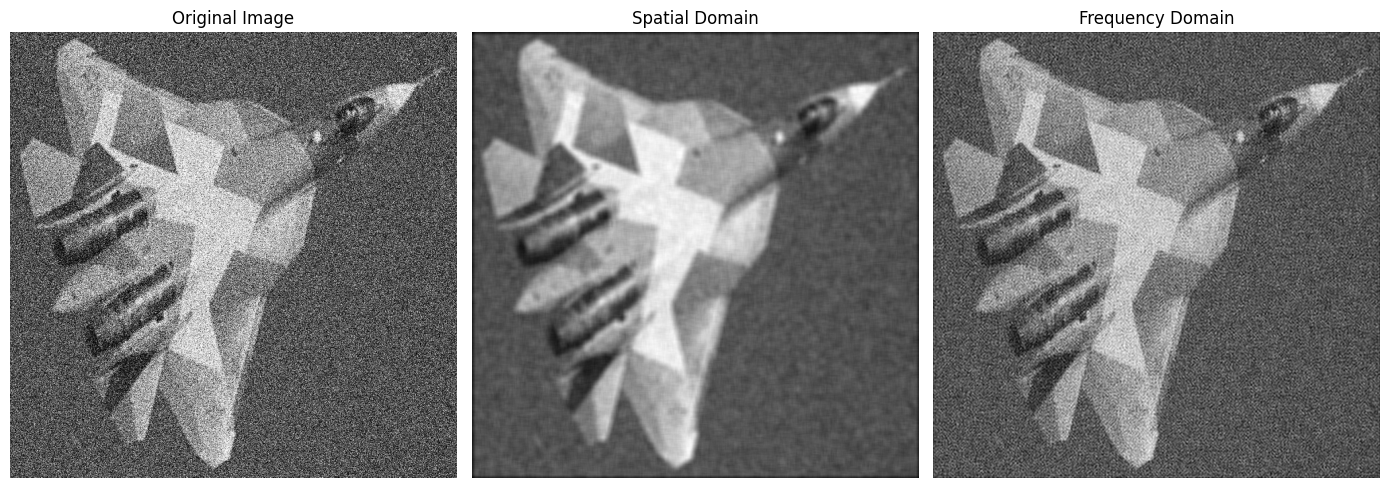

In [18]:
#Ex5_5: Noise Reduction using Low-Pass Filter (LPF)
Img = cv2.imread(PATH + 'airplane.png')
# Convert from BGR to GRAYSCALE, then normalize to double format
Img = cv2.cvtColor(Img, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

# Construct a frequency meshgrid
wx, wy = np.meshgrid(np.arange(-np.pi, np.pi+np.pi/5, np.pi/5), np.arange(-np.pi, np.pi+np.pi/5, np.pi/5))
# wx, wy are ranging from -pi to pi with the step = pi/5

# Choose either one of three filters
#type_filter = "1d_horizontal"
#type_filter = "1d_vertical"
type_filter = "2d_box"

if type_filter == "2d_box":
  # Spatial domain
  h = np.ones((10, 10), np.float64) / 100
  # Frequency domain
  H = (1/100) * (1 + 2*np.cos(wx) + 2*np.cos(2*wx)) * (1 + 2*np.cos(wy) + 2*np.cos(2*wy))
elif type_filter == "1d_horizontal":
  # Spatial domain
  h = np.ones((1, 10), np.float64) / 10
  # Frequency domain
  H = (1/10) * (1 + 2*np.cos(wx) + 2*np.cos(2*wx))
else: #type_filter == "1d_vertical"
  # Spatial domain
  h = np.ones((10, 1), np.float64) / 10
  # Frequency domain
  H = (1/10) * (1 + 2*np.cos(wy) + 2*np.cos(2*wy))

# Display the frequency domain filter
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(wx / np.pi, wy / np.pi, np.abs(H), cmap='viridis')
ax.set_xticks(np.arange(-1, 1.1, 0.5)), ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel(r'$\omega_x / \pi$', fontsize=FS), ax.set_ylabel(r'$\omega_y / \pi$', fontsize=FS)
ax.set_zlabel(r'$|H(\omega_x, \omega_y)|$', fontsize=FS)

plt.tight_layout()
plt.savefig(PATH + 'Ex5_5a.jpg', dpi=400)
plt.show()

# Apply spatial domain and frequency domain filters to the noisy image
from scipy.signal import convolve2d as conv2

filtered_Img1 = cv2.filter2D(Img, -1, h, borderType=cv2.BORDER_CONSTANT) # spatial domain
filtered_Img2 = conv2(Img, H, mode='same') # frequency domain

# Display results
plt.figure(figsize=(14,10))

plt.subplot(1, 3, 1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(filtered_Img1, cmap='gray'), plt.title('Spatial Domain', fontsize=FS), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(filtered_Img2, cmap='gray'), plt.title('Frequency Domain', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex5_5b.jpg', dpi=400)
plt.show()


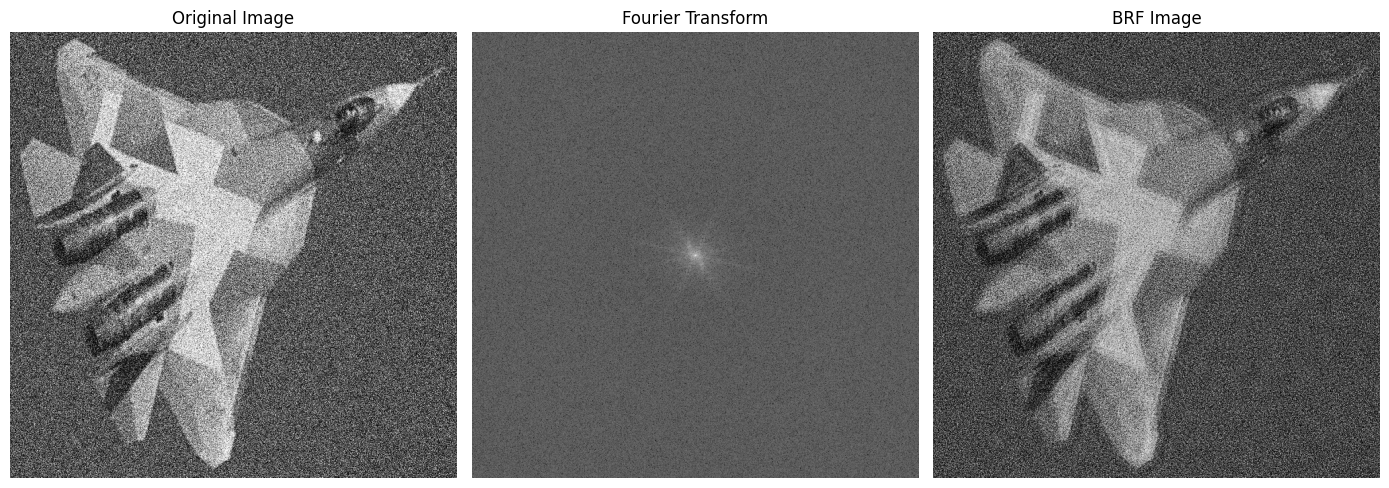

In [19]:
# Ex5_6: Noise Reduction using band Reject Filter (BRF)
# Image -> FFT -> Band Reject Filter -> IFFT -> Filtered Image

Img = cv2.imread(PATH + 'airplane.png')

# Convert from bgr to Gray, then normalize to double (0 -> 1)
Img = cv2.cvtColor(Img, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

# Compute Fourier Transform of the image
f = np.fft.fft2(Img)
# Shift the zero-frequency component to the center of the spectrum.
f_shift = np.fft.fftshift(f)

# Compute the center coordinates of the frequency spectrum
row, col = Img.shape
crow, ccol = row // 2, col // 2

# Create the Band Reject Filter
D0 = 40 #center frequency
W = 20

# Initial the frequency mask with all frequencies passed
mask = np.ones((row, col), np.float64)


for u in range(row):
  for v in range(col):
    D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2) # Compute the distance from the current frequency point to the spectrum center.
    if (D0 - W/2) <= D <= (D0 + W/2):              # Reject frequencies that fall within the specified band.
      mask[u,v] = 0


# Apply the filter to the original image
filtered_shift = f_shift * mask

# Inverse FFT
f_ishift = np.fft.ifftshift(filtered_shift)
Img_converted = np.fft.ifft2(f_ishift)
Img_converted = np.abs(Img_converted)

# Normalize the converted image to display
Img_converted = cv2.normalize(Img_converted, 0, 255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)

# Display results
plt.figure(figsize = (14,10))

plt.subplot(1,3,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize = FS)
plt.axis('off')
plt.subplot(1,3,2), plt.imshow(np.log(np.abs(f_shift)+1), cmap='gray'), plt.title('Fourier Transform', fontsize = FS)
plt.axis('off')
plt.subplot(1,3,3), plt.imshow(Img_converted, cmap='gray'), plt.title('BRF Image', fontsize = FS)
plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex5_6.jpg', dpi=400)
plt.show()